# 📊 Báo cáo Tổng quan Tiệm Vàng Đà Nẵng
> Phân tích 150+ tiệm vàng crawl từ Google Maps

**Mục tiêu**: Hiểu phân bổ tiệm vàng theo quận, chất lượng dịch vụ, và cơ hội thị trường.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

shops = pd.read_csv('../data/shops.csv')
reviews = pd.read_csv('../data/reviews.csv')
prices = pd.read_csv('../data/prices.csv')

print(f'Total shops: {len(shops)}')
print(f'Total reviews: {len(reviews)}')
print(f'Total price records: {len(prices)}')
shops.head(3)

Total shops: 150
Total reviews: 527
Total price records: 42


,id,name,address,district,lat,lng,phone,hours,rating,review_count,website,google_maps_url,source,is_verified,created_at
0,1,Tiệm Vàng Kim Khánh Việt Hùng,"215 Hùng Vương, Phước Ninh, Hải Châu, Đà Nẵng",Hải Châu,16.0544,108.2022,0236 3822 xxx,07:30 - 20:00,3.6,36,NaN,https://www.google.com/maps/place/V%C3%A0ng+B%...,manual,True,2026-03-14 05:14:09
1,2,PNJ Đà Nẵng - Hùng Vương,"78 Hùng Vương, Hải Châu, Đà Nẵng",Hải Châu,16.0678,108.2109,1800 1626,08:00 - 21:00,4.9,49,https://www.pnj.com.vn,NaN,official,True,2026-03-14 05:14:09
2,3,PNJ Đà Nẵng - Ông Ích Khiêm,"265 Ông Ích Khiêm, Hải Châu, Đà Nẵng",Hải Châu,16.0521,108.2187,1800 1626,08:00 - 21:00,4.9,49,https://www.pnj.com.vn,https://www.google.com/maps/place/C%E1%BB%ADa+...,official,True,2026-03-14 05:14:09


## 1. Phân bổ tiệm vàng theo quận

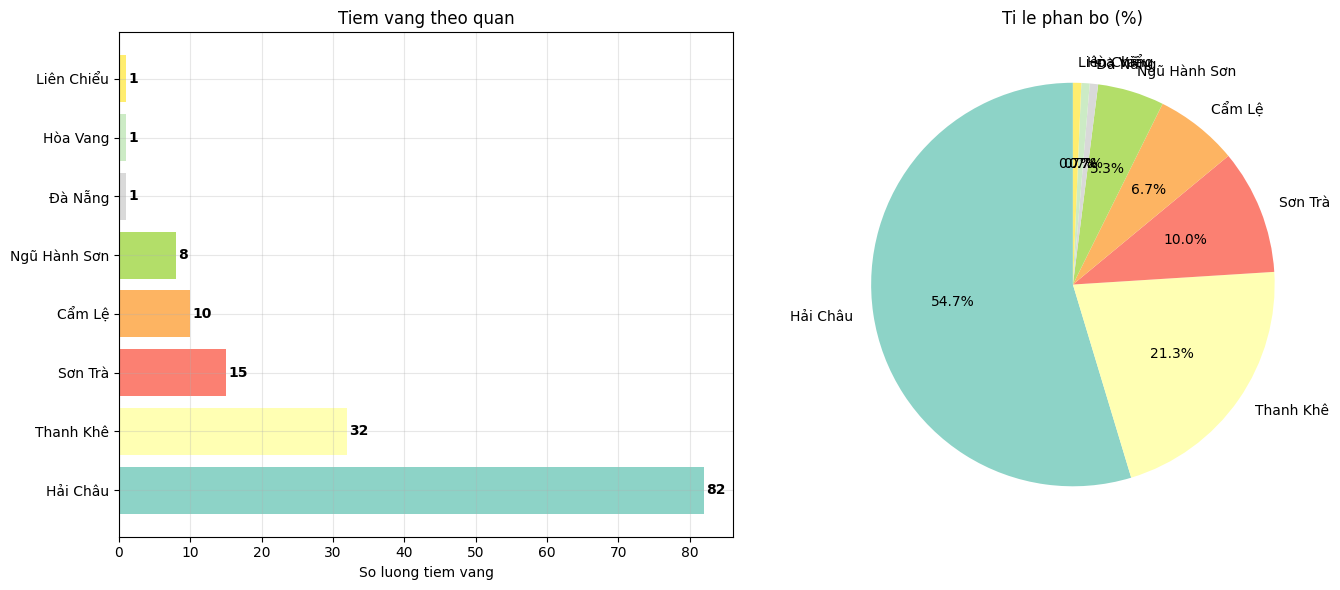


Top 3 quan nhieu tiem vang nhat:
district
Hải Châu     82
Thanh Khê    32
Sơn Trà      15
Name: count, dtype: int64


In [2]:
district_counts = shops['district'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, len(district_counts)))
axes[0].barh(district_counts.index, district_counts.values, color=colors)
axes[0].set_xlabel('So luong tiem vang')
axes[0].set_title('Tiem vang theo quan')
for i, v in enumerate(district_counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

# Pie chart
axes[1].pie(district_counts.values, labels=district_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Ti le phan bo (%)')

plt.tight_layout()
plt.savefig('../data/district_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTop 3 quan nhieu tiem vang nhat:')
print(district_counts.head(3))

## 2. Phân tích Rating — Đội uy tín

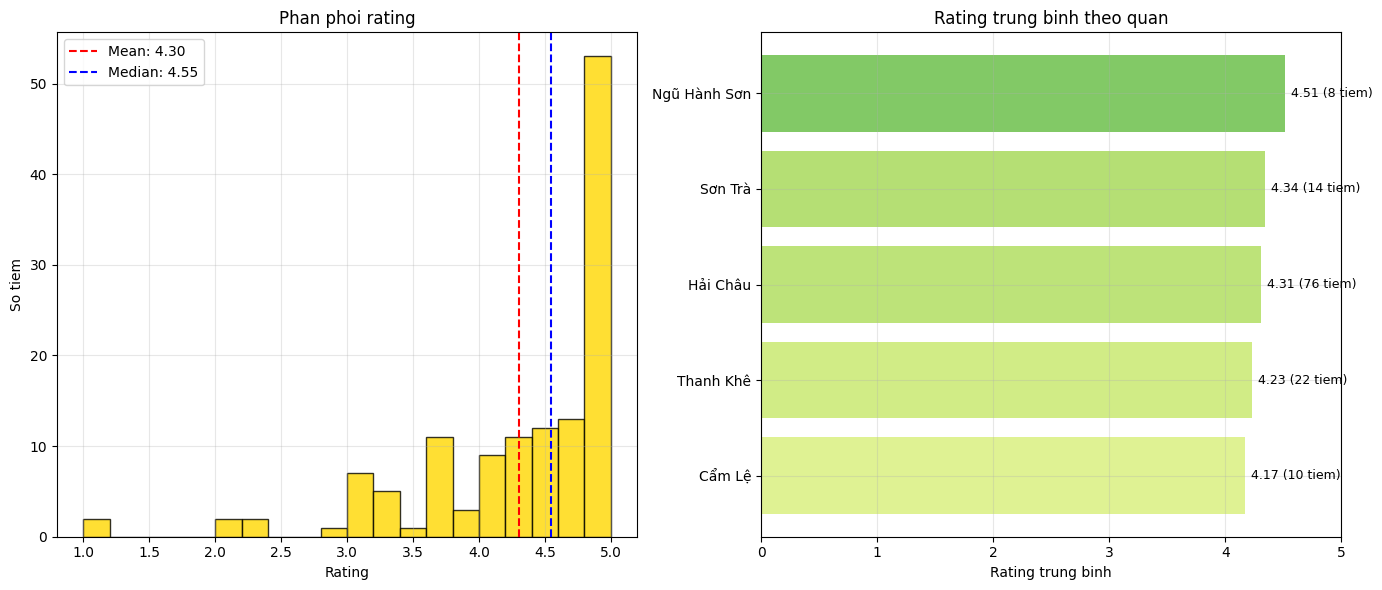

In [3]:
shops_rated = shops[shops['rating'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rating distribution
axes[0].hist(shops_rated['rating'], bins=20, color='gold', edgecolor='black', alpha=0.8)
axes[0].axvline(shops_rated['rating'].mean(), color='red', linestyle='--',
                label=f'Mean: {shops_rated["rating"].mean():.2f}')
axes[0].axvline(shops_rated['rating'].median(), color='blue', linestyle='--',
                label=f'Median: {shops_rated["rating"].median():.2f}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('So tiem')
axes[0].set_title('Phan phoi rating')
axes[0].legend()

# Rating by district
dist_rating = shops_rated.groupby('district')['rating'].agg(['mean', 'count']).reset_index()
dist_rating = dist_rating[dist_rating['count'] >= 3].sort_values('mean', ascending=True)
bars = axes[1].barh(dist_rating['district'], dist_rating['mean'],
                    color=[plt.cm.RdYlGn((v - 3) / 2) for v in dist_rating['mean']])
axes[1].set_xlabel('Rating trung binh')
axes[1].set_title('Rating trung binh theo quan')
axes[1].set_xlim(0, 5)
for bar, val, cnt in zip(bars, dist_rating['mean'], dist_rating['count']):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} ({cnt} tiem)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Top 20 tiệm vàng uy tín nhất

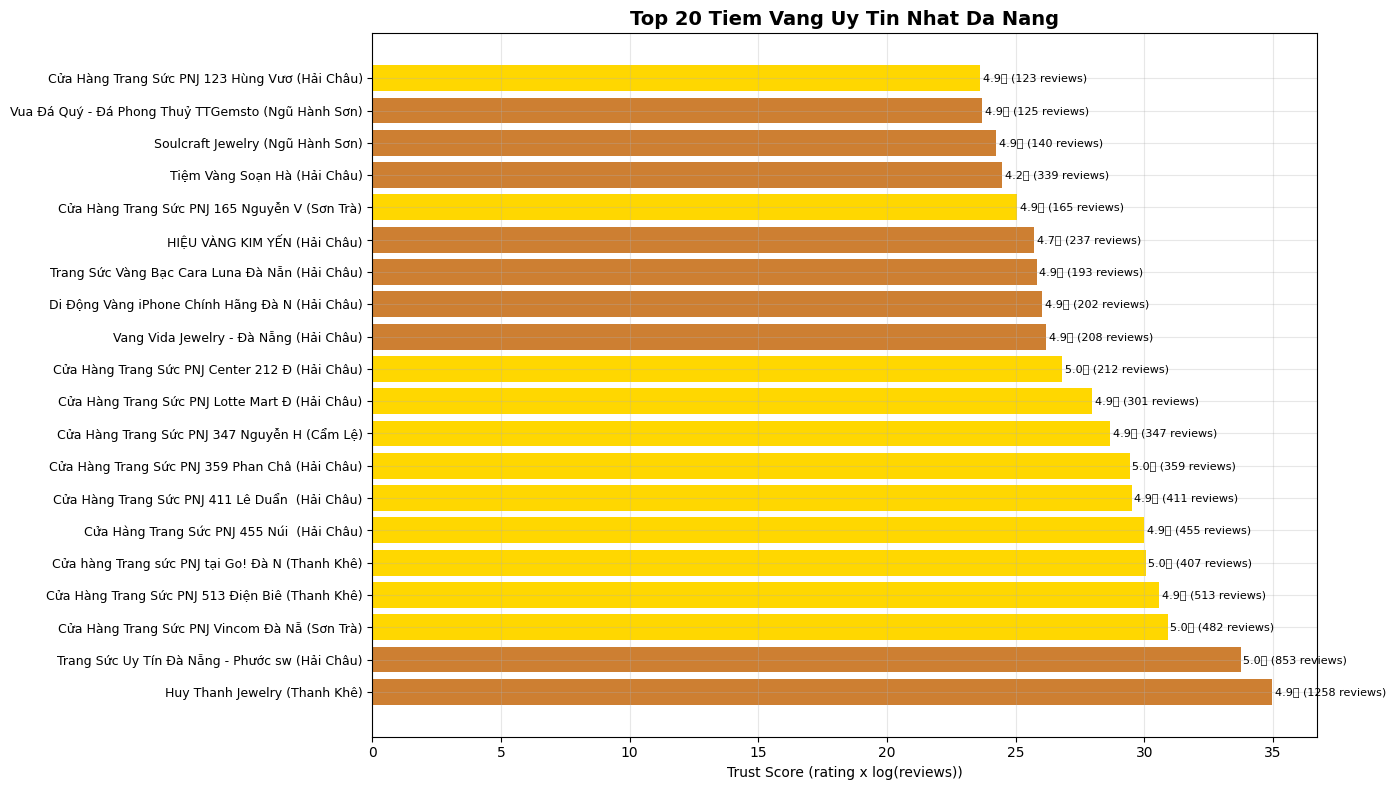


=== TOP 20 TIEM VANG UY TIN ===
                                               name     district  rating  review_count_filled  trust_score
                                  Huy Thanh Jewelry    Thanh Khê     4.9                 1258    34.976558
             Trang Sức Uy Tín Đà Nẵng - Phước swiss     Hải Châu     5.0                  853    33.749656
              Cửa Hàng Trang Sức PNJ Vincom Đà Nẵng      Sơn Trà     5.0                  482    30.900083
   Cửa Hàng Trang Sức PNJ 513 Điện Biên Phủ Đà Nẵng    Thanh Khê     4.9                  513    30.586894
             Cửa hàng Trang sức PNJ tại Go! Đà Nẵng    Thanh Khê     5.0                  407    30.056336
Cửa Hàng Trang Sức PNJ 455 Núi Thành Đà Nẵng     Hải Châu     4.9                  455    30.000215
         Cửa Hàng Trang Sức PNJ 411 Lê Duẩn Đà Nẵng     Hải Châu     4.9                  411    29.503014
 Cửa Hàng Trang Sức PNJ 359 Phan Châu Trinh Đà Nẵng     Hải Châu     5.0                  359    29.430520
Cửa 

In [4]:
# Weighted score: rating * log(review_count + 1)
shops_rated['review_count_filled'] = shops_rated['review_count'].fillna(0)
shops_rated['trust_score'] = shops_rated['rating'] * np.log1p(shops_rated['review_count_filled'])

top20 = shops_rated.nlargest(20, 'trust_score')[['name', 'district', 'rating', 'review_count_filled', 'trust_score']]

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#FFD700' if 'PNJ' in n else '#C0C0C0' if 'DOJI' in n else '#CD7F32'
          for n in top20['name']]
bars = ax.barh(range(len(top20)), top20['trust_score'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f"{r['name'][:35]} ({r['district']})" for _, r in top20.iterrows()], fontsize=9)
ax.set_xlabel('Trust Score (rating x log(reviews))')
ax.set_title('Top 20 Tiem Vang Uy Tin Nhat Da Nang', fontsize=14, fontweight='bold')
for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row["rating"]}⭐ ({int(row["review_count_filled"])} reviews)', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../data/top20_shops.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== TOP 20 TIEM VANG UY TIN ===')
print(top20[['name', 'district', 'rating', 'review_count_filled', 'trust_score']].to_string(index=False))

## 4. Phân tích review count — Mức độ phổ biến

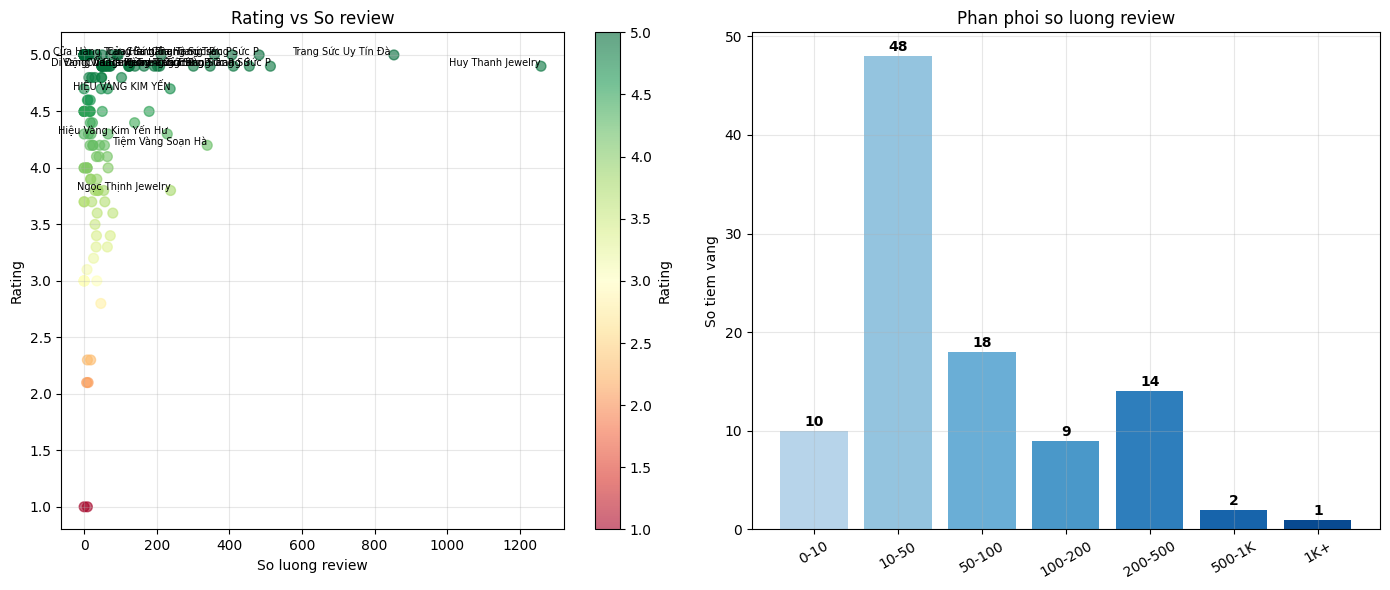

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: rating vs review_count
sc = axes[0].scatter(shops_rated['review_count_filled'], shops_rated['rating'],
                     alpha=0.6, c=shops_rated['rating'], cmap='RdYlGn',
                     s=50, vmin=1, vmax=5)
plt.colorbar(sc, ax=axes[0], label='Rating')
axes[0].set_xlabel('So luong review')
axes[0].set_ylabel('Rating')
axes[0].set_title('Rating vs So review')

# Highlight notable shops
notable = shops_rated[shops_rated['review_count_filled'] > 200]
for _, row in notable.iterrows():
    axes[0].annotate(row['name'][:20],
                     (row['review_count_filled'], row['rating']),
                     fontsize=7, ha='right')

# Review count distribution
bins = [0, 10, 50, 100, 200, 500, 1000, 5000]
labels = ['0-10', '10-50', '50-100', '100-200', '200-500', '500-1K', '1K+']
shops_rated['review_bucket'] = pd.cut(shops_rated['review_count_filled'], bins=bins, labels=labels)
bucket_counts = shops_rated['review_bucket'].value_counts().sort_index()
axes[1].bar(range(len(bucket_counts)), bucket_counts.values,
            color=plt.cm.Blues(np.linspace(0.3, 0.9, len(bucket_counts))))
axes[1].set_xticks(range(len(bucket_counts)))
axes[1].set_xticklabels(bucket_counts.index, rotation=30)
axes[1].set_ylabel('So tiem vang')
axes[1].set_title('Phan phoi so luong review')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/reviews_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Thống kê tổng hợp

In [6]:
print('=== TONG KET TONG QUAN ===')
print(f'Tong so tiem vang: {len(shops)}')
print(f'Co rating: {len(shops_rated)} ({len(shops_rated)/len(shops)*100:.1f}%)')
print(f'Rating trung binh: {shops_rated["rating"].mean():.2f}')
print(f'Tiem rating >= 4.5: {len(shops_rated[shops_rated["rating"]>=4.5])}')
print(f'Tiem rating < 3.5: {len(shops_rated[shops_rated["rating"]<3.5])}')
print(f'\nQuan nhieu tiem nhat: {district_counts.index[0]} ({district_counts.iloc[0]} tiem)')
print(f'Quan it tiem nhat: {district_counts.index[-1]} ({district_counts.iloc[-1]} tiem)')
print(f'\nTong reviews: {len(reviews)}')
print(f'Reviews trung binh/tiem: {shops_rated["review_count_filled"].mean():.1f}')

print('\n=== PHAN LOAI UY TIN ===')
excellent = shops_rated[shops_rated['rating'] >= 4.7]
good = shops_rated[(shops_rated['rating'] >= 4.0) & (shops_rated['rating'] < 4.7)]
average = shops_rated[(shops_rated['rating'] >= 3.0) & (shops_rated['rating'] < 4.0)]
poor = shops_rated[shops_rated['rating'] < 3.0]
print(f'Excellent (>=4.7): {len(excellent)} tiem')
print(f'Good (4.0-4.7):    {len(good)} tiem')
print(f'Average (3.0-4.0): {len(average)} tiem')
print(f'Poor (<3.0):       {len(poor)} tiem')

=== TONG KET TONG QUAN ===
Tong so tiem vang: 150
Co rating: 132 (88.0%)
Rating trung binh: 4.30
Tiem rating >= 4.5: 75
Tiem rating < 3.5: 19

Quan nhieu tiem nhat: Hải Châu (82 tiem)
Quan it tiem nhat: Liên Chiểu (1 tiem)

Tong reviews: 527
Reviews trung binh/tiem: 83.8

=== PHAN LOAI UY TIN ===
Excellent (>=4.7): 63 tiem
Good (4.0-4.7):    35 tiem
Average (3.0-4.0): 27 tiem
Poor (<3.0):       7 tiem
